In [1]:
# WEB DEV TEAM PLEASE DELETE BEFORE PUBLISHING - DS TEAM PLEASE KEEP IN THE FINAL VERSION OF THE USE CASE

from IPython.core.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');
body,p,li,div{font-family:'Inter',sans-serif}
body{counter-reset:h2counter}
.usecase-header-bar,.usecase-title,.usecase-section-heading,.usecase-sub-section-heading,.usecase-sub-sub-section-heading,.usecase-unnumbered-heading{font-family:'Poppins',sans-serif}
.usecase-header-bar{padding:16px 20px;background-color:#059669;color:#fff;border-radius:6px 6px 0 0}
.usecase-title{font-size:1.9em;font-weight:800}
.usecase-details{padding-left:20px;padding-bottom:8px;padding-top:8px;font-size:1.1em;color:#121212}
.usecase-section-heading,.usecase-unnumbered-heading{font-weight:700;font-size:1.35em;color:#059669;padding:14px 4px 6px 4px;border-bottom:3px solid #2DBE6C;margin-top:10px}
.usecase-section-heading::before{content:none!important}
.usecase-sub-section-heading{font-weight:600;font-size:1.15em;color:#059669;margin-top:8px}
.usecase-sub-section-heading::before{content:none!important}
.usecase-sub-sub-section-heading{font-weight:500;font-size:1.05em;color:#059669;margin-top:6px}
.usecase-sub-sub-section-heading::before{content:none!important}
.usecase-body{font-size:1em;color:#121212;line-height:1.6;margin-bottom:8px}
.usecase-list{line-height:1.7}
.usecase-list ul,.usecase-list ol{padding-left:24px;margin-top:8px;margin-bottom:12px}
.usecase-list li{margin-bottom:6px}
.usecase-datasets{background-color:rgba(5,150,105,.06);border-left:4px solid #059669;padding:12px 20px;border-radius:0 4px 4px 0;margin-top:12px}
.usecase-datasets ul{margin-top:8px;margin-bottom:8px}
.usecase-contents a,.usecase-datasets a{color:#059669;text-decoration:none}
.usecase-datasets a{font-weight:500}
.usecase-contents a:hover,.usecase-datasets a:hover{text-decoration:underline}
.usecase-contents{line-height:1.9;padding-left:20px}
</style>
""")

<div class="usecase-header-bar">
    <div class="usecase-title">Melbourne Soil Analysis 2024 - 2025</div>
</div>

<div class="usecase-details"><b>Authored by: </b>Thomas Rostov</div>
<div class="usecase-details"><b>Date Created: </b>Trimester 2, 2024</div>
<div class="usecase-details"><b>Time to Complete: </b>60 mins</div>
<div class="usecase-details"><b>Level: </b>Intermediate</div>
<div class="usecase-details"><b>Pre-requisite Skills: </b>Python, pandas, matplotlib and REST APIs</div>

<div id="scenario" class="usecase-unnumbered-heading"><b>Scenario</b></div>

<div class="usecase-body">

As a parks and gardens supervisor, I want to see how soil temperature and salinity change with depth and across the city, so that watering and planting decisions are based on what the ground is actually doing rather than on the weather.

</div>

<div id="what-this-teaches" class="usecase-unnumbered-heading"><b>What this usecase will teach you</b></div>

<div class="usecase-body">

After working through this use case you will be able to:

</div>

<div class="usecase-list">

- Retrieve an open dataset from the City of Melbourne Open Data Portal using its Explore API (Application Programming Interface).
- Page through an API that returns records in batches, so that a large dataset can be collected into one DataFrame.
- Turn a nested JSON (JavaScript Object Notation) response into a table with `pandas.json_normalize`.
- Handle API errors so that a failed request tells you what went wrong.
- Tidy up inconsistent category labels before filtering on them.
- Compare soil temperature at 10, 20 and 30 cm (centimetres) using line charts and histograms.
- Explain how depth changes the way soil temperature behaves.
- Map the sensor sites with `folium`, using marker clustering to keep a busy map readable.
- Apply the same steps to a second measure, soil salinity.

</div>

<div id="background" class="usecase-unnumbered-heading"><b>Background</b></div>

<div class="usecase-body">

The City of Melbourne runs a network of soil sensors buried in parks, gardens and street tree plots across the city. They support the council's urban forest program, where the practical question is usually whether the ground needs water. Surface weather cannot answer that on its own, because soil holds heat and moisture for longer than the air above it.

Each sensor takes readings at several depths, and reports several measures at each depth. The data is published in long format: every row is a single observation, tagged by a `probe_measure` label such as "Soil Temperature 10cm", along with its value, the site and the time. Filtering that long format is most of the preparation work below.

Two datasets are needed. The readings carry the measurements but no coordinates. The locations carry the coordinates but no measurements. They are joined on site.

</div>

<div id="data-sets" class="usecase-unnumbered-heading"><b>Data Sets</b></div>

<div class="usecase-body">

Both datasets are retrieved live through the Opendatasoft Explore API, so the notebook always works against the current release rather than a stored copy. They are published by the City of Melbourne under a Creative Commons Attribution licence, and neither contains personal information. The two are designed to be used together and are joined on `site_id`.

The readings dataset is the time series: one row per probe, per measure, per moment. The locations dataset is a small reference table of around 58 sites, giving each one a name, the park it sits in, and its coordinates.

</div>

<div class="usecase-datasets">

- [Soil Sensor Readings (Historical Data)](https://data.melbourne.vic.gov.au/explore/dataset/soil-sensor-readings-historical-data/)
- [Soil Sensor Locations](https://data.melbourne.vic.gov.au/explore/dataset/soil-sensor-locations/)

</div>

<div id="fields" class="usecase-unnumbered-heading"><b>Fields you will use</b></div>

<div class="usecase-body">

**Soil Sensor Readings**

| Field | Description |
| --- | --- |
| `local_time` | When the reading was taken. Use this as the time axis. |
| `site_id` | Sensor site. Joins to the locations dataset. |
| `site_name` | Readable name of the sensor. |
| `probe_measure` | What was measured and at what depth. |
| `soil_value` | The reading itself. |
| `unit` | Unit for `soil_value`. |
| `timestamp` | When the record was published, **not** when the reading was taken. |

**Soil Sensor Locations**

| Field | Description |
| --- | --- |
| `site_id` | Sensor site. Joins to the readings dataset. |
| `site_name` | Readable name of the sensor. |
| `property_name` | The park or garden. Empty for street and laneway sites. |
| `latitude`, `longitude` | Coordinates, returned as text. |

Both also carry `id`, `size` and `json_featuretype`, which are portal internals rather than data.

</div>

<div class="usecase-body">

Three things are worth knowing before you start.

`probe_measure` is messy. The column holds over a hundred labels for what are really three measures at eight depths, because the same reading has been spelled several ways over the years. Section 4.1 tidies this up.

`timestamp` is not the reading time. It is when the record was published, and it is the same across large blocks of rows. `local_time` is the one you want.

Without an API key the portal will not serve records past an offset of 10,000, so the notebook collects 9,900 rows. That is a sample of the series, not the whole history.

</div>

<div id="contents" class="usecase-unnumbered-heading"><b>Contents</b></div>

<div class="usecase-contents">

1. <a href="#section-1">Set up the Python environment</a><br>
2. <a href="#section-2">Retrieve the soil sensor readings</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;2.1. <a href="#section-2-1">Build the API request</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;2.2. <a href="#section-2-2">Define the retrieval functions</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;2.3. <a href="#section-2-3">Retrieve the full dataset</a><br>
3. <a href="#section-3">Inspect the structure of the data</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1. <a href="#section-3-1">Work through a single API call</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.2. <a href="#section-3-2">Assemble the complete dataset</a><br>
4. <a href="#section-4">Explore the soil temperature readings</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.1. <a href="#section-4-1">Separate the readings by depth</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.2. <a href="#section-4-2">Compare the three depths</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.3. <a href="#section-4-3">Distribution of the readings</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.4. <a href="#section-4-4">Temperature at each depth individually</a><br>
5. <a href="#section-5">Map the soil sensor locations</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.1. <a href="#section-5-1">Retrieve the sensor location data</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.2. <a href="#section-5-2">Plot the sensors on an interactive map</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.3. <a href="#section-5-3">Cluster the markers</a><br>
6. <a href="#section-6">Examine soil salinity</a><br>
7. <a href="#section-7">From readings to decisions</a><br>

</div>

<div id="section-1" class="usecase-section-heading">
    1. Set up the Python environment
</div>

<div class="usecase-body">

In this section we will import the libraries used for data retrieval, analysis, visualisation and mapping throughout the use case. We use `requests` to call the API, `pandas` to handle the data, `matplotlib` and `seaborn` for the charts, and `folium` for the map in section 5.

</div>

In [ ]:
%pip install folium

Note: you may need to restart the kernel to use updated packages.


<div class="usecase-body">

Folium does not come with Anaconda, so it is installed first. `%pip` is used rather than a bare `pip` because it installs into the kernel running this notebook.

</div>

In [ ]:
# Data retrieval and handling
import requests
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping
import folium
from folium.plugins import MarkerCluster

MOP_GREEN = '#059669'   # Primary Green
MOP_PURPLE = '#9333EA'  # Distinct Purple
MOP_BLUE = '#2563EB'    # Distinct Blue

# The template asks for the palette to be used in order, so the three depths
# take the first colours in turn.
DEPTH_COLOURS = {'10 cm': MOP_GREEN, '20 cm': MOP_PURPLE, '30 cm': MOP_BLUE}

<div id="section-2" class="usecase-section-heading">
    2. Retrieve the soil sensor readings
</div>

<div class="usecase-body">

The City of Melbourne Open Data Portal exposes every dataset through the Opendatasoft Explore API. In this section we build the request, then wrap the paging logic in a few reusable functions.

</div>

<div id="section-2-1" class="usecase-sub-section-heading">
    2.1. Build the API request
</div>

<div class="usecase-body">

An API request is built from three parts: the catalogue base URL, the dataset name as it appears on the portal, and a query string that controls the response. The query string carries three settings. `limit` is how many records to return, and cannot be higher than 100. `offset` is where in the series to start. `timezone=UTC` returns timestamps in Coordinated Universal Time (UTC), so they stay on one consistent clock.

</div>

In [ ]:
base_url = 'https://data.melbourne.vic.gov.au/api/explore/v2.0/catalog/datasets/'
dataset = 'soil-sensor-readings-historical-data'
number_of_records = 100

filters = f'records?limit={number_of_records}&offset=0&timezone=UTC'

soil_reading_url = f'{base_url}{dataset}/{filters}'
soil_reading_url

'https://data.melbourne.vic.gov.au/api/explore/v2.0/catalog/datasets/soil-sensor-readings-historical-data/records?limit=100&offset=0&timezone=UTC'

<div class="usecase-body">

Printing the URL is a good habit. You can paste it into a browser and see exactly what the notebook is asking for, which makes a bad request much easier to spot.

</div>

<div id="section-2-2" class="usecase-sub-section-heading">
    2.2. Define the retrieval functions
</div>

<div class="usecase-body">

The API returns records in pages, so collecting the full series means calling it repeatedly and moving `offset` forward each time. The functions below do that. Every request goes through `call_api`. Keeping the checks in one place means each call stays readable, and a failure anywhere reports what actually went wrong. Four things can go wrong: the request never arrives, the response is not JSON, the portal returns an error instead of data, or the status code is unsuccessful for some other reason. One catch is that the portal spells its error key two ways &mdash; `error_code` for a bad request and `errorcode` for an exhausted quota &mdash; so both are checked.

</div>

In [ ]:

def call_api(url, timeout=30):
    """Send a request to the Explore API and return the parsed JSON payload.

    Parameters
    ----------
    url : str
        The fully assembled request URL.
    timeout : int
        Seconds to wait for a response before giving up.

    Returns
    -------
    dict
        The parsed JSON response.

    Raises
    ------
    RuntimeError
        If the request could not be sent, the response was not JSON, or the
        portal reported an error instead of returning data.
    """
    
    try:
        response = requests.get(url, timeout=timeout)
    except requests.exceptions.Timeout:
        raise RuntimeError(
            f'The request timed out after {timeout} seconds. The portal may be '
            f'slow or unreachable; try again, or raise the timeout.'
        )
    except requests.exceptions.ConnectionError:
        raise RuntimeError(
            'Could not reach the Open Data Portal. Check your internet '
            'connection and that the URL is correct:\n' + url
        )

    try:
        payload = response.json()
    except ValueError:
        raise RuntimeError(
            f'Expected JSON but received a {response.status_code} response '
            f'that could not be parsed:\n{response.text[:200]}'
        )

   
    if isinstance(payload, dict):
        if 'errorcode' in payload:
            
            raise RuntimeError(
                f"Request quota exceeded ({response.status_code}). "
                f"{payload.get('error')} The limit is "
                f"{payload.get('call_limit'):,} calls per "
                f"{payload.get('limit_time_unit')}, resetting at "
                f"{payload.get('reset_time')}."
            )
        if 'error_code' in payload:
            
            raise RuntimeError(
                f"The API rejected the request ({response.status_code} "
                f"{payload['error_code']}): {payload.get('message')}"
            )

    response.raise_for_status()

    return payload

In [ ]:
# Function that extracts the data from the JSON
def get_data(base, data_url, offset = 0):

    filters = f'records?limit={100}&offset={offset}&timezone=UTC'
    url = f'{base}{data_url}/{filters}'
    
    result_json = call_api(url)

    max_results = result_json['total_count']
    links = result_json['links']
    records = result_json['records']
    records_df = pd.json_normalize(records)

    records_df.drop(columns=['links'],inplace=True)
    column_names = records_df.columns.values.tolist()

    column_names = [i.split('.')[-1] for i in column_names]
    records_df.columns = column_names

    next_url = None

    if records_df.shape[0] != max_results:
        for l in links:
            if l['rel']=='next':
                next_url = l['href']

    return [records_df, next_url, column_names]

<div class="usecase-body">

`get_data` fetches one page. It builds the URL, sends the request through `call_api`, flattens the JSON into a table, and works out whether there is another page to fetch. `json_normalize` names its columns after the full nested path, so a field arrives as something like `record.fields.soil_value`. Splitting on the full stop and keeping the last part shortens that to `soil_value`.

</div>

In [ ]:
def add_to_dataframe(pages):
    """Join a list of retrieved pages into one DataFrame.

    Concatenating the list once, rather than joining each page onto a growing
    frame, keeps the column dtypes intact.
    """
    if not pages:
        return pd.DataFrame()
    return pd.concat(pages, ignore_index=True)

<div class="usecase-body">

`add_to_dataframe` joins the collected pages together. Combining them in one step keeps the column types intact.

</div>

In [8]:
# Extracts the data from the url to produce a pandas dataset
def extract_dataframe(base, dataset_id, max_records=9900):
    """Page through the API and assemble the records into one DataFrame.

    Takes the base URL as an argument rather than reading it from the global
    namespace, so the function cannot be affected by a later cell reassigning it.
    """
    pages = []
    rows = 0
    url_next = True

    while url_next is not None and rows < max_records:
        df_new, url_next, column_names = get_data(base, dataset_id, rows)

        # An empty page means the portal has no more records to give.
        if df_new.empty:
            break

        pages.append(df_new)
        rows += len(df_new)
        print(f'Retrieved {rows:,} records', end='\r')

    if not pages:
        return pd.DataFrame()

    # Concatenating the list once, rather than joining each page onto a growing
    # frame, keeps the column dtypes intact and avoids the FutureWarning raised
    # by concatenating onto an empty DataFrame.
    #
    # Without an API key the portal will not serve records past an offset of
    # 10,000, which is why paging stops at 9,900.
    return add_to_dataframe(pages).head(max_records)

<div class="usecase-body">

`extract_dataframe` drives the loop: fetch a page, add it, repeat until there are no more. It stops at 9,900 rows because the portal will not serve past an offset of 10,000 without an API key.

</div>

<div id="section-2-3" class="usecase-sub-section-heading">
    2.3. Retrieve the full dataset
</div>

<div class="usecase-body">

Now we call the driver function to collect the readings into a single DataFrame. This makes around 99 requests, so give it a minute or two.

</div>

In [9]:
# Call the driver function to page through the readings and assemble them
# into a single DataFrame. This makes roughly 99 sequential requests.
soil_df = extract_dataframe(base_url, dataset)

print(f'Retrieved {len(soil_df):,} rows and {soil_df.shape[1]} columns.')
soil_df.head()

Retrieved 9,900 rows and 13 columns.


,id,timestamp,size,local_time,site_name,site_id,id,probe_id,probe_measure,soil_value,unit,json_featuretype,year
0,f6d64274e3cb1055cf8226a0aa437460ec90e306,2026-05-07T04:51:38.553Z,116,2024-02-23T15:00:00+00:00,Queen Vic,66204,21317888,1338798,Soil Moisture 80cm #0,43.63,%VWC,Output,None
1,59a752078b6704af8357d4b85f1b9a66e41b8f09,2026-05-07T04:51:38.553Z,144,2024-02-23T17:00:00+00:00,Royal Parade University college,70829,21317952,1495863,Soil Salinity 20cm #0,0.29,µS/cm,Output,None
2,2411b817a5f9e9e73a8a9f204b3577252c0a0142,2026-05-07T04:51:38.553Z,144,2024-05-28T17:00:00+00:00,Royal Parade University college,70829,22944291,1495875,Soil Temperature 50cm #0,13.03,ºC,Output,None
3,55e949aa7054578ab82a5ecb375a8db2897e3228,2026-05-07T04:51:38.553Z,127,2024-02-23T13:00:00+00:00,Princess bridge NW p01,101032,21314968,2019259,Soil Moisture 30cm,10.27,%VWC,Output,None
4,110e710535d3371dac3b326add58828493a776ba,2026-05-07T04:51:38.553Z,127,2024-05-28T16:00:00+00:00,McAlister Oval,64975,22944415,1320462,Soil Salinity 20cm #0,0.21,µS/cm,Output,None


<div id="section-3" class="usecase-section-heading">
    3. Inspect the structure of the data
</div>

<div class="usecase-body">

Before analysing anything, it is worth seeing what a raw API response looks like. This section unpacks a single call step by step.

</div>

<div id="section-3-1" class="usecase-sub-section-heading">
    3.1. Work through a single API call
</div>

<div class="usecase-body">

Running one request by hand shows what `get_data` does internally. The result is kept as `sample_df` so that it does not overwrite the full dataset collected above.

</div>

In [10]:
# Use requests to get the data.
# This section deliberately inspects the raw response step by step, so the call
# is made directly rather than through call_api. A timeout is still set: without
# one, a request that never answers will hang the notebook indefinitely.
result = requests.get(soil_reading_url, timeout=30)

print('Status code:', result.status_code)

Status code: 200


<div class="usecase-body">

`requests.get` returns a response object rather than the data itself. It carries the status code, the headers and the raw body, and the JSON has to be read out of it.

</div>

In [11]:
result_json = result.json()
result_json.keys()

dict_keys(['total_count', 'links', 'records'])

<div class="usecase-body">

Checking the top-level keys before reading any of them is the most useful habit when working with a new API. A good response carries `total_count` and the records. A bad one carries an error code and a message instead. `total_count` is how many records exist on the portal, not how many came back. That gap is why paging is needed.


</div>

In [12]:
# The same checks call_api performs, applied here explicitly so the failure
# modes are visible rather than hidden inside a function.
if 'errorcode' in result_json:
    raise RuntimeError(f"Quota exceeded: {result_json.get('error')} "
                       f"Resets at {result_json.get('reset_time')}.")

if 'error_code' in result_json:
    raise RuntimeError(f"{result_json['error_code']}: {result_json.get('message')}")

# v2.0 names this key 'records'; v2.1 renamed it to 'results'.
records = result_json.get('records', result_json.get('results', []))

if not records:
    raise RuntimeError('The response contained no records. Check the dataset '
                       'name and the query parameters in the URL above.')

print(f'{len(records)} records returned.')

100 records returned.


<div class="usecase-body">

The record list is where the data sits. Each entry is nested rather than a flat row, which is why it needs flattening next.

</div>

In [ ]:
sample_df = pd.json_normalize(records)

sample_df = sample_df.drop(columns=['links'], errors='ignore')

sample_df.head()

,record.id,record.timestamp,record.size,record.fields.local_time,record.fields.site_name,record.fields.site_id,record.fields.id,record.fields.probe_id,record.fields.probe_measure,record.fields.soil_value,record.fields.unit,record.fields.json_featuretype,record.fields.year
0,f6d64274e3cb1055cf8226a0aa437460ec90e306,2026-05-07T04:51:38.553Z,116,2024-02-23T15:00:00+00:00,Queen Vic,66204,21317888,1338798,Soil Moisture 80cm #0,43.63,%VWC,Output,None
1,59a752078b6704af8357d4b85f1b9a66e41b8f09,2026-05-07T04:51:38.553Z,144,2024-02-23T17:00:00+00:00,Royal Parade University college,70829,21317952,1495863,Soil Salinity 20cm #0,0.29,µS/cm,Output,None
2,2411b817a5f9e9e73a8a9f204b3577252c0a0142,2026-05-07T04:51:38.553Z,144,2024-05-28T17:00:00+00:00,Royal Parade University college,70829,22944291,1495875,Soil Temperature 50cm #0,13.03,ºC,Output,None
3,55e949aa7054578ab82a5ecb375a8db2897e3228,2026-05-07T04:51:38.553Z,127,2024-02-23T13:00:00+00:00,Princess bridge NW p01,101032,21314968,2019259,Soil Moisture 30cm,10.27,%VWC,Output,None
4,110e710535d3371dac3b326add58828493a776ba,2026-05-07T04:51:38.553Z,127,2024-05-28T16:00:00+00:00,McAlister Oval,64975,22944415,1320462,Soil Salinity 20cm #0,0.21,µS/cm,Output,None


<div class="usecase-body">

`json_normalize` turns the nested records into a table, one row each. The column names it produces are the full nested paths, so they are tidied in the next cell.

</div>

In [14]:
# Tidy the column names by keeping only the final part of each nested path.
sample_df.columns = [name.split('.')[-1] for name in sample_df.columns]

# 'id' is an internal record hash rather than anything useful for analysis.
sample_df = sample_df.drop(columns='id', errors='ignore')

sample_df.head()

,timestamp,size,local_time,site_name,site_id,probe_id,probe_measure,soil_value,unit,json_featuretype,year
0,2026-05-07T04:51:38.553Z,116,2024-02-23T15:00:00+00:00,Queen Vic,66204,1338798,Soil Moisture 80cm #0,43.63,%VWC,Output,None
1,2026-05-07T04:51:38.553Z,144,2024-02-23T17:00:00+00:00,Royal Parade University college,70829,1495863,Soil Salinity 20cm #0,0.29,µS/cm,Output,None
2,2026-05-07T04:51:38.553Z,144,2024-05-28T17:00:00+00:00,Royal Parade University college,70829,1495875,Soil Temperature 50cm #0,13.03,ºC,Output,None
3,2026-05-07T04:51:38.553Z,127,2024-02-23T13:00:00+00:00,Princess bridge NW p01,101032,2019259,Soil Moisture 30cm,10.27,%VWC,Output,None
4,2026-05-07T04:51:38.553Z,127,2024-05-28T16:00:00+00:00,McAlister Oval,64975,1320462,Soil Salinity 20cm #0,0.21,µS/cm,Output,None


<div class="usecase-body">

Splitting each name on the full stop turns `record.fields.soil_value` into `soil_value`. The `id` column is dropped because it is an internal record hash. The four columns that matter from here on are `local_time`, `probe_measure`, `soil_value` and `site_name`.

</div>

In [15]:
sample_df

,timestamp,size,local_time,site_name,site_id,probe_id,probe_measure,soil_value,unit,json_featuretype,year
0,2026-05-07T04:51:38.553Z,116,2024-02-23T15:00:00+00:00,Queen Vic,66204,1338798,Soil Moisture 80cm #0,43.63,%VWC,Output,None
1,2026-05-07T04:51:38.553Z,144,2024-02-23T17:00:00+00:00,Royal Parade University college,70829,1495863,Soil Salinity 20cm #0,0.29,µS/cm,Output,None
2,2026-05-07T04:51:38.553Z,144,2024-05-28T17:00:00+00:00,Royal Parade University college,70829,1495875,Soil Temperature 50cm #0,13.03,ºC,Output,None
3,2026-05-07T04:51:38.553Z,127,2024-02-23T13:00:00+00:00,Princess bridge NW p01,101032,2019259,Soil Moisture 30cm,10.27,%VWC,Output,None
4,2026-05-07T04:51:38.553Z,127,2024-05-28T16:00:00+00:00,McAlister Oval,64975,1320462,Soil Salinity 20cm #0,0.21,µS/cm,Output,None
...,...,...,...,...,...,...,...,...,...,...,...
95,2026-05-07T04:51:38.553Z,139,2024-02-23T15:00:00+00:00,Shrine Reserve South East,64989,1305487,Soil Moisture 80cm #0 (Clay),27.92,%VWC,Output,None
96,2026-05-07T04:51:38.553Z,135,2024-02-23T17:00:00+00:00,Treasury Gardens South,64977,1305986,Soil Salinity 60cm #0,0.48,µS/cm,Output,None
97,2026-05-07T04:51:38.553Z,120,2024-02-23T15:00:00+00:00,Treasury West,75509,1619055,Soil Moisture 50cm #0,31.27,%VWC,Output,None
98,2026-05-07T04:51:38.553Z,132,2024-02-23T13:30:00+00:00,Princess bridge SE P01,101036,2019325,Soil Temperature 40cm,23.40,ºC,Output,None


<div id="section-3-2" class="usecase-sub-section-heading">
    3.2. Assemble the complete dataset
</div>

<div class="usecase-body">

The full dataset was collected in section 2.3. A quick summary is a useful checkpoint before moving on.

</div>

In [ ]:

print(f'Rows: {len(soil_df):,}')
print(f'Columns: {soil_df.shape[1]}')
print(f'Distinct sites: {soil_df["site_name"].nunique()}')

Rows: 9,900
Columns: 13
Distinct sites: 58


<div class="usecase-body">

The data is in long format. Instead of one column per measurement, every row holds a single observation tagged by `probe_measure`, with the site and the time. Sensor data is often published this way because sensors report different measures at different depths. It does mean almost every question starts with a filter.

</div>

In [17]:
soil_df.head()

,id,timestamp,size,local_time,site_name,site_id,id,probe_id,probe_measure,soil_value,unit,json_featuretype,year
0,f6d64274e3cb1055cf8226a0aa437460ec90e306,2026-05-07T04:51:38.553Z,116,2024-02-23T15:00:00+00:00,Queen Vic,66204,21317888,1338798,Soil Moisture 80cm #0,43.63,%VWC,Output,None
1,59a752078b6704af8357d4b85f1b9a66e41b8f09,2026-05-07T04:51:38.553Z,144,2024-02-23T17:00:00+00:00,Royal Parade University college,70829,21317952,1495863,Soil Salinity 20cm #0,0.29,µS/cm,Output,None
2,2411b817a5f9e9e73a8a9f204b3577252c0a0142,2026-05-07T04:51:38.553Z,144,2024-05-28T17:00:00+00:00,Royal Parade University college,70829,22944291,1495875,Soil Temperature 50cm #0,13.03,ºC,Output,None
3,55e949aa7054578ab82a5ecb375a8db2897e3228,2026-05-07T04:51:38.553Z,127,2024-02-23T13:00:00+00:00,Princess bridge NW p01,101032,21314968,2019259,Soil Moisture 30cm,10.27,%VWC,Output,None
4,110e710535d3371dac3b326add58828493a776ba,2026-05-07T04:51:38.553Z,127,2024-05-28T16:00:00+00:00,McAlister Oval,64975,22944415,1320462,Soil Salinity 20cm #0,0.21,µS/cm,Output,None


<div id="section-4" class="usecase-section-heading">
    4. Explore the soil temperature readings
</div>

<div class="usecase-body">

The readings are in long format, so we first look at what the sensors record, then pull out the ones we want. This section works through soil temperature at three depths.

</div>

<div id="section-4-1" class="usecase-sub-section-heading">
    4.1. Separate the readings by depth
</div>

<div class="usecase-body">

Listing the distinct values of `probe_measure` shows what the sensors report.

</div>

In [18]:
# The same physical reading appears under many different labels.
print(f"{soil_df['probe_measure'].nunique()} distinct probe_measure labels")
soil_df['probe_measure'].unique()[:15]

110 distinct probe_measure labels


array(['Soil Moisture 80cm #0', 'Soil Salinity 20cm #0',
       'Soil Temperature 50cm #0', 'Soil Moisture 30cm',
       'Soil Temperature 30cm #0', 'Soil Moisture 70cm #0',
       'Soil Moisture 70cm #0 (Clay)',
       'Soil Moisture 20cm #0 (Sandy Loam)', 'Soil Salinity 70cm',
       'Soil Temperature 60cm #0', 'Soil Salinity 80cm #0',
       'Soil Moisture 20cm #0 (Sand)', 'Soil Moisture 70cm #0 (Sand)',
       'Soil Salinity 40 cm #0', '#0 Soil Moisture 60cm'], dtype=object)

<div class="usecase-body">

Two preparation steps are needed before charting.

First, `local_time` and `soil_value` arrive as text. Left that way, matplotlib treats every timestamp as a separate category and prints all of them along the axis.

Second, the labels need tidying. Rather than matching an exact label, we pull the measure and the depth out with a regular expression, so every spelling of the same reading is treated the same way.

</div>

In [ ]:
soil_df['local_time'] = pd.to_datetime(soil_df['local_time'], errors='coerce', format='mixed')
soil_df['soil_value'] = pd.to_numeric(soil_df['soil_value'], errors='coerce')


soil_df['measure_type'] = soil_df['probe_measure'].str.extract(
    r'(Temperature|Moisture|Salinity)', expand=False
)
soil_df['depth_cm'] = soil_df['probe_measure'].str.extract(
    r'(\d+)\s*cm', expand=False
).astype('Int64')


def readings_for(df, measure_type, depth_cm):
    """Return every reading of one measure at one depth, sorted by time."""
    subset = df[(df['measure_type'] == measure_type) & (df['depth_cm'] == depth_cm)]
    return subset.sort_values(by='local_time')

pd.crosstab(soil_df['measure_type'], soil_df['depth_cm'])

depth_cm,10,20,30,40,50,60,70,80
measure_type,,,,,,,,
Moisture,759,807,774,799,420,469,456,428
Salinity,370,319,325,333,187,165,173,203
Temperature,378,381,400,364,223,225,207,224


<div class="usecase-body">

The list above is longer than it should be. Three measures at eight depths would be about twenty-four labels, but the column holds over a hundred. The reason is that the same reading has been written several ways over the years. `Soil Temperature 10cm #0`, `Soil Temperature 10cm` and `Soil Temperature 010cm` are all the same measurement. Matching one exact label would quietly return only part of the data, or none at all.

</div>

In [20]:
Temperature_10 = readings_for(soil_df, 'Temperature', 10)

print(f'{len(Temperature_10):,} readings')
Temperature_10.head()

378 readings


,id,timestamp,size,local_time,site_name,site_id,id,probe_id,probe_measure,soil_value,unit,json_featuretype,year,measure_type,depth_cm
530,0a901b568d3cd850959b4cef46fd252b36ff36c9,2026-05-07T04:51:38.553Z,133,2024-02-14 10:30:00+00:00,Princess bridge NE p11,101037,21164999,2019343,Soil Temperature 10cm,15.43,ºC,Output,None,Temperature,10
579,887c7a5285bd239b7ee7e465a0d33736d283fbbe,2026-05-07T04:51:38.553Z,126,2024-02-14 11:00:00+00:00,Bourke North 3,65008,21171392,1311609,Soil Temperature 10cm #0,20.60,ºC,Output,None,Temperature,10
519,f3771a55e0070096d01ba34da6b81eb2203473a4,2026-05-07T04:51:38.553Z,131,2024-02-14 11:00:00+00:00,Royal Parade South,72758,21169790,1495943,Soil Temperature 10cm #0,18.69,ºC,Output,None,Temperature,10
302,56e36e42ded63f4195130d458ba6637d2005a1d9,2026-05-07T04:51:38.553Z,127,2024-02-14 11:00:00+00:00,Bourke South 5,66191,21165488,1310388,Soil Temperature 10cm #0,21.66,ºC,Output,None,Temperature,10
236,2503513bfc37ff8042894ef672f6ae2d1f7e9652,2026-05-07T04:51:38.553Z,145,2024-02-14 11:00:00+00:00,Alexandra Gardens Engineers Lawn,66195,21163720,1338736,Soil Temperature 10cm #0,19.61,ºC,Output,None,Temperature,10


<div class="usecase-body">

`readings_for` selects the rows for one measure at one depth and sorts them by time. Sorting matters: the API returns records in no particular order, and an unsorted line chart is unreadable.

</div>

In [21]:
Temperature_20 = readings_for(soil_df, 'Temperature', 20)

print(f'{len(Temperature_20):,} readings')
Temperature_20.head()

381 readings


,id,timestamp,size,local_time,site_name,site_id,id,probe_id,probe_measure,soil_value,unit,json_featuretype,year,measure_type,depth_cm
640,e6f9a1633ed9012938b4162089d35b5d870e42eb,2026-05-07T04:51:38.553Z,122,2024-02-14 11:00:00+00:00,8th Green,64980,21171913,1304457,Soil Temperature 20cm #0,17.77,ºC,Output,None,Temperature,20
531,c40359d0a183e07ce88b88990f8c7e67c943dcbd,2026-05-07T04:51:38.553Z,125,2024-02-14 11:00:00+00:00,Western Oval,64974,21165064,1304380,Soil Temperature 20cm #0,19.34,ºC,Output,None,Temperature,20
213,b97ddf6d5bb0da8b0b07c382a62f00b1d32b089c,2026-05-07T04:51:38.553Z,135,2024-02-14 11:00:00+00:00,Princess bridge East p06,101038,21161653,2019364,Soil Temperature 20cm,19.84,ºC,Output,None,Temperature,20
392,1f97ac7903202efb116a6b4d3790a2a09dde63b5,2026-05-07T04:51:38.553Z,125,2024-02-14 11:00:00+00:00,Natures Play,75500,21167560,1618818,Soil Temperature 20cm #0,19.42,ºC,Output,None,Temperature,20
843,066ddd1222e1cae1127ac7c9ca067f84bbeb6a66,2026-05-07T04:51:38.553Z,131,2024-02-14 13:00:00+00:00,Royal Parade South,72758,21172350,1495944,Soil Temperature 20cm #0,20.37,ºC,Output,None,Temperature,20


In [22]:
Temperature_30 = readings_for(soil_df, 'Temperature', 30)

print(f'{len(Temperature_30):,} readings')
Temperature_30.head()

400 readings


,id,timestamp,size,local_time,site_name,site_id,id,probe_id,probe_measure,soil_value,unit,json_featuretype,year,measure_type,depth_cm
453,1e9c632e5cf10914e6205b777436c655d8f7a832,2026-05-07T04:51:38.553Z,134,2024-02-14 11:00:00+00:00,Treasury Gardens North,64988,21169456,1305955,Soil Temperature 30cm #0,18.70,ºC,Output,None,Temperature,30
473,bb483b078d193f0f418c894ddad3750cf03d2e60,2026-05-07T04:51:38.553Z,133,2024-02-14 11:00:00+00:00,Flemington Road Oval,65013,21164027,1304944,Soil Temperature 30cm #0,19.87,ºC,Output,None,Temperature,30
796,e2a30587661d4399eb849ee38435270cfa3ce383,2026-05-07T04:51:38.553Z,144,2024-02-14 11:00:00+00:00,Alexandra Gardens Engineers Lawn,66195,21169480,1338738,Soil Temperature 30cm #0,21.50,ºC,Output,None,Temperature,30
652,948b3c129068e411529ad7eaf914d3b374504c7c,2026-05-07T04:51:38.553Z,133,2024-02-14 11:00:00+00:00,Bourke North 6 (280),66202,21172225,1310500,Soil Temperature 30cm #0,23.18,ºC,Output,None,Temperature,30
661,81e4be4d1b6c67434e1bdd4964972d6a62465f19,2026-05-07T04:51:38.553Z,133,2024-02-14 11:30:00+00:00,Princess bridge NW p01,101032,21171760,2019264,Soil Temperature 30cm,22.07,ºC,Output,None,Temperature,30


<div class="usecase-body">

The same is done for 20 cm and 30 cm, giving three series to compare.

</div>

<div id="section-4-2" class="usecase-sub-section-heading">
    4.2. Compare the three depths
</div>

<div class="usecase-body">

Plotting all three depths on one set of axes lets us compare them directly.

</div>

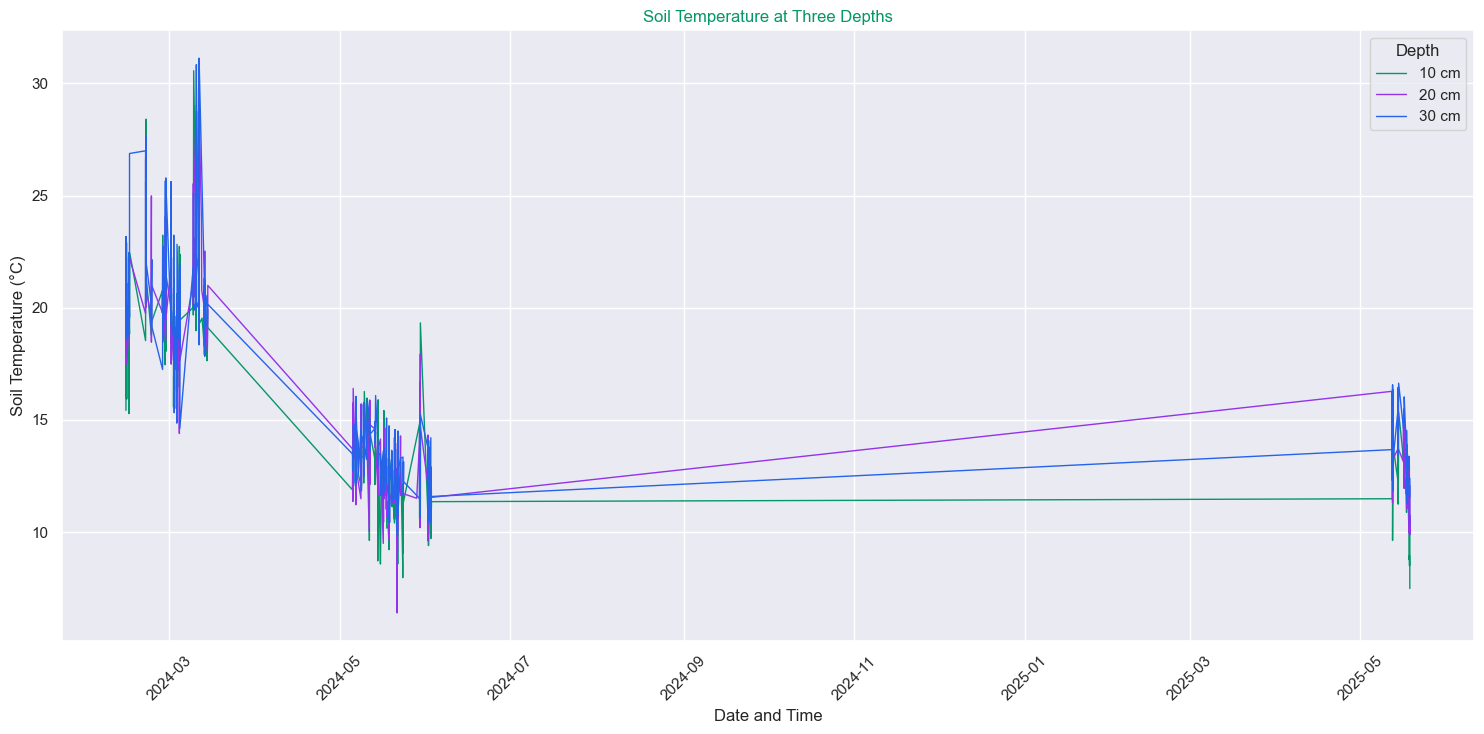

In [23]:
sns.set_theme()
fig, ax = plt.subplots(figsize=(15, 7.5))

ax.plot(Temperature_10['local_time'], Temperature_10['soil_value'],
        label='10 cm', linewidth=1, color=DEPTH_COLOURS['10 cm'])
ax.plot(Temperature_20['local_time'], Temperature_20['soil_value'],
        label='20 cm', linewidth=1, color=DEPTH_COLOURS['20 cm'])
ax.plot(Temperature_30['local_time'], Temperature_30['soil_value'],
        label='30 cm', linewidth=1, color=DEPTH_COLOURS['30 cm'])

ax.set_xlabel("Date and Time")
ax.set_ylabel("Soil Temperature (\u00b0C)")
ax.set_title("Soil Temperature at Three Depths", color=MOP_GREEN)

ax.tick_params(axis='x', rotation=45)
ax.legend(title='Depth')

plt.tight_layout()
plt.show()

<div class="usecase-body">

The three lines show the same soil at three depths, so any difference between them comes from depth alone. Look at how far each line swings. The 10 cm readings sit closest to the surface and follow the daily heating and cooling of the air, so they move the most. The 30 cm readings are insulated by the soil above and should move less, with their peaks arriving later. This is why a surface reading is a poor guide to the root zone, which is where watering decisions actually apply. Note that each line combines every sensor in the network, so sites in full sun and under tree canopy are mixed together.

</div>

<div id="section-4-3" class="usecase-sub-section-heading">
    4.3. Distribution of the readings
</div>

<div class="usecase-body">

The line chart shows when readings happened. A histogram shows how often each value occurred, ignoring time.

</div>

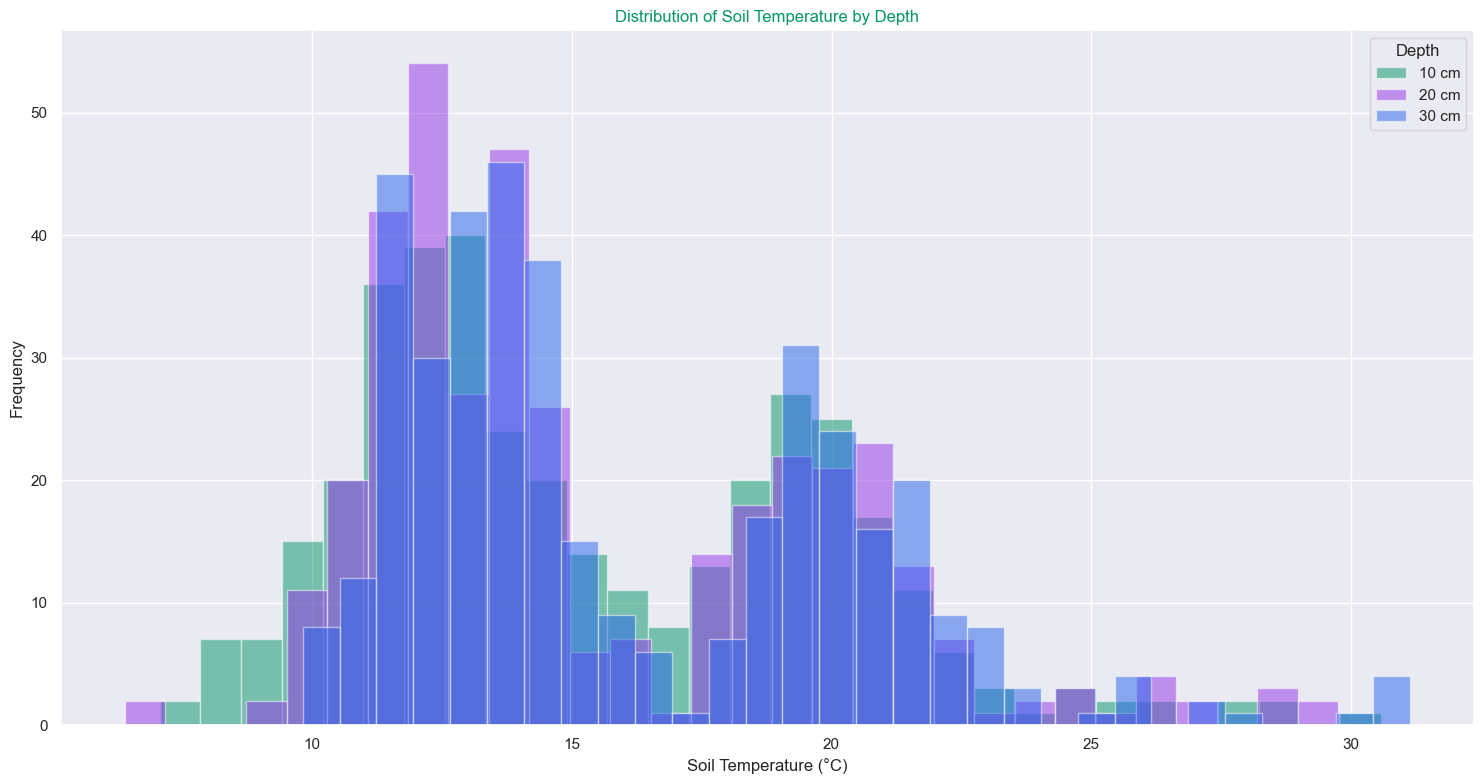

In [24]:
sns.set_theme()
plt.figure(figsize=(15, 8))

plt.hist(Temperature_10['soil_value'].dropna(), bins=30, alpha=0.5,
         label='10 cm', color=DEPTH_COLOURS['10 cm'])
plt.hist(Temperature_20['soil_value'].dropna(), bins=30, alpha=0.5,
         label='20 cm', color=DEPTH_COLOURS['20 cm'])
plt.hist(Temperature_30['soil_value'].dropna(), bins=30, alpha=0.5,
         label='30 cm', color=DEPTH_COLOURS['30 cm'])

plt.xlabel("Soil Temperature (\u00b0C)")
plt.ylabel("Frequency")
plt.title("Distribution of Soil Temperature by Depth", color=MOP_GREEN)

plt.legend(title='Depth')
plt.tight_layout()
plt.show()

<div class="usecase-body">

The width of each distribution is the thing to read. A narrow, tall shape means the readings cluster around a typical value. A wide, flat shape means they are spread out. Depth should order them, with 30 cm narrowest. Two shapes are worth watching for. Two separate peaks usually mean two populations have been mixed, most often summer and winter readings. A long tail on one side means occasional extreme values, which are worth checking before trusting.

</div>

<div id="section-4-4" class="usecase-sub-section-heading">
    4.4. Temperature at each depth individually
</div>

<div class="usecase-body">

Plotting each depth on its own axes removes the shared scale of the combined chart, so the shape of each series is easier to see.

</div>

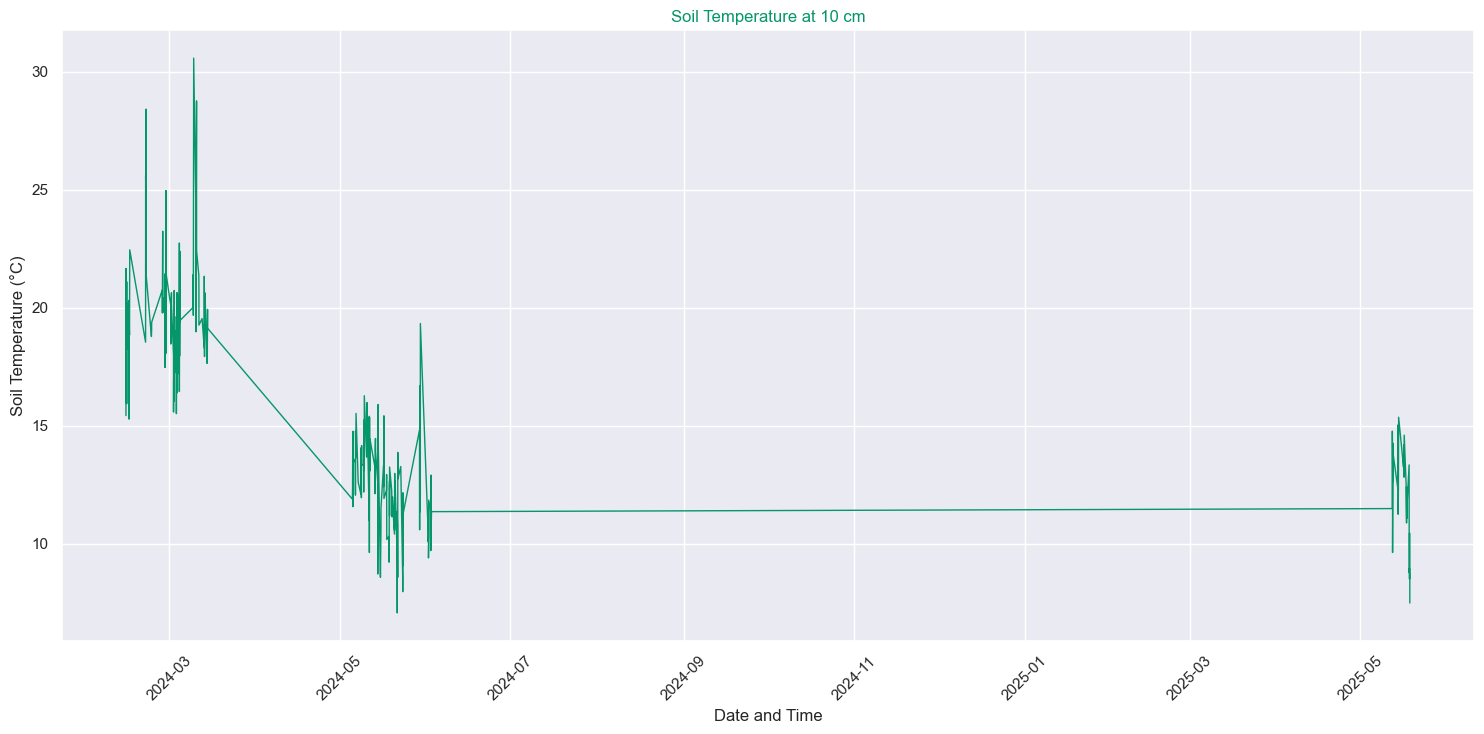

In [25]:
sns.set_theme()
fig, ax = plt.subplots(figsize=(15, 7.5))

ax.plot(Temperature_10['local_time'], Temperature_10['soil_value'],
        linewidth=1, color=DEPTH_COLOURS['10 cm'])

ax.set_xlabel("Date and Time")
ax.set_ylabel("Soil Temperature (\u00b0C)")
ax.set_title("Soil Temperature at 10 cm", color=MOP_GREEN)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

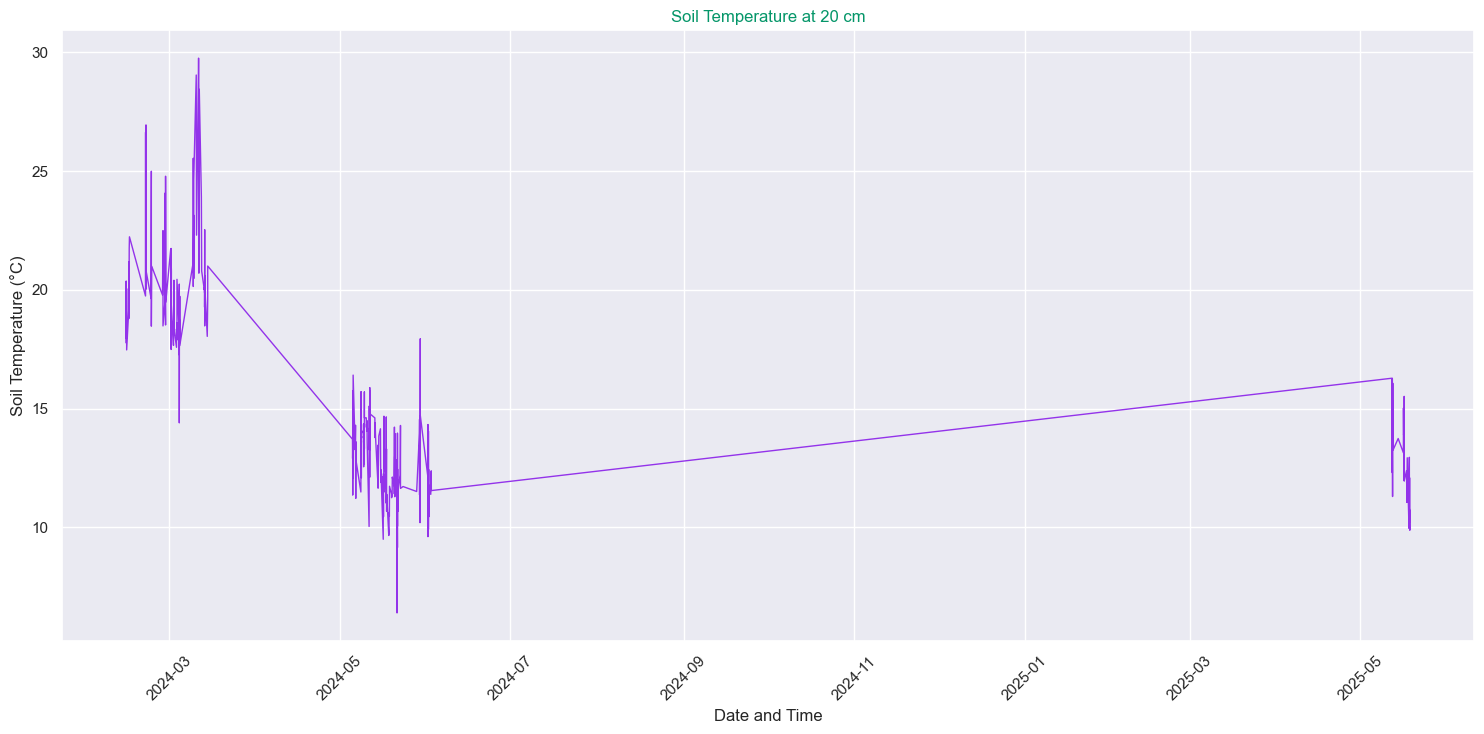

In [26]:
sns.set_theme()
fig, ax = plt.subplots(figsize=(15, 7.5))

ax.plot(Temperature_20['local_time'], Temperature_20['soil_value'],
        linewidth=1, color=DEPTH_COLOURS['20 cm'])

ax.set_xlabel("Date and Time")
ax.set_ylabel("Soil Temperature (\u00b0C)")
ax.set_title("Soil Temperature at 20 cm", color=MOP_GREEN)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

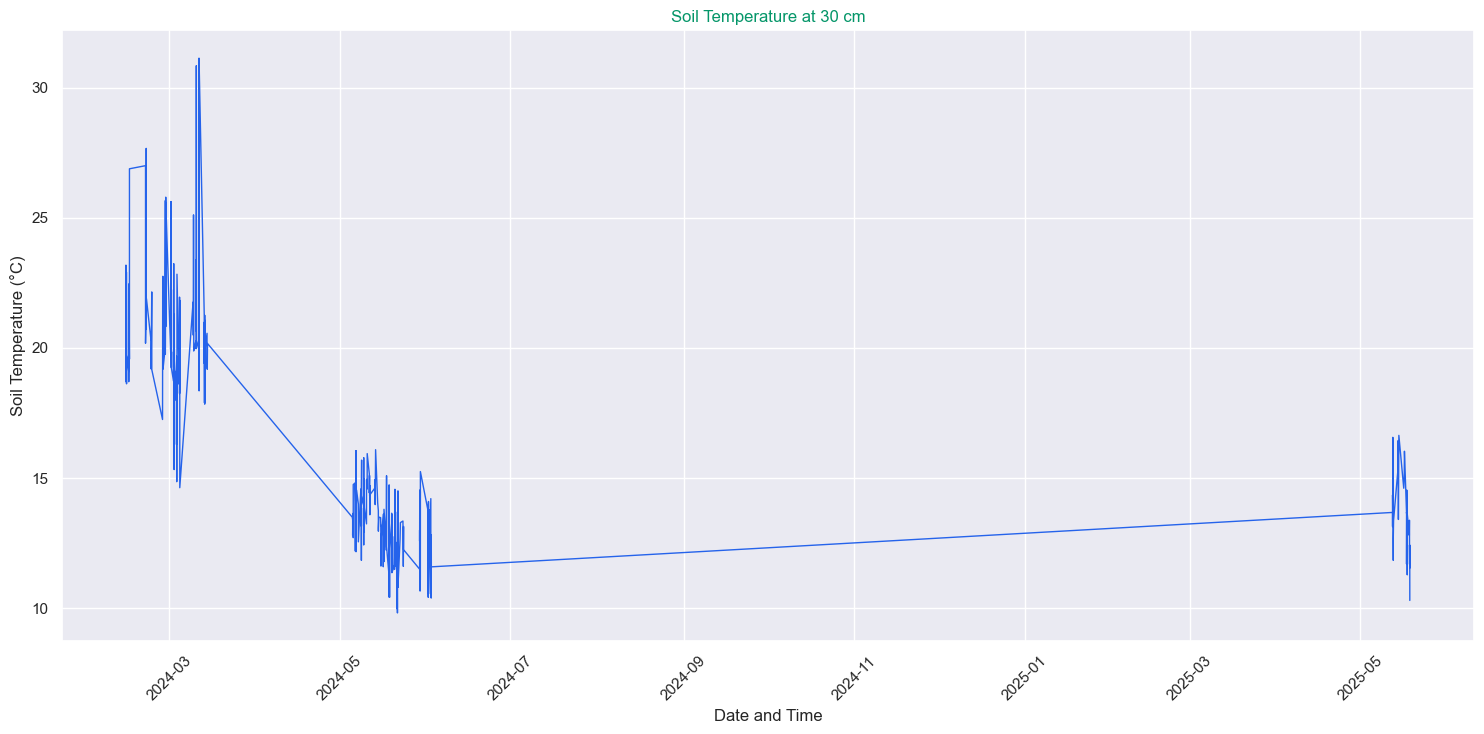

In [27]:
sns.set_theme()
fig, ax = plt.subplots(figsize=(15, 7.5))

ax.plot(Temperature_30['local_time'], Temperature_30['soil_value'],
        linewidth=1, color=DEPTH_COLOURS['30 cm'])

ax.set_xlabel("Date and Time")
ax.set_ylabel("Soil Temperature (\u00b0C)")
ax.set_title("Soil Temperature at 30 cm", color=MOP_GREEN)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<div class="usecase-body">

On the combined chart the three series share one scale wide enough to hold them all, which flattens each line. Separately, each uses the full height of its own plot. This is a good place for a data quality check. Flat sections usually mean a sensor stopped reporting and the last value was repeated. Sudden vertical jumps are larger than soil temperature can really change, and normally point to a fault.

</div>

<div id="section-5" class="usecase-section-heading">
    5. Map the soil sensor locations
</div>

<div class="usecase-body">

The readings carry no coordinates, so a second dataset is needed to place each sensor on a map. In this section we retrieve it and build an interactive map of the network.

</div>

<div id="section-5-1" class="usecase-sub-section-heading">
    5.1. Retrieve the sensor location data
</div>

<div class="usecase-body">

The locations dataset is small, so one request covers it.

</div>

In [ ]:
# The locations dataset is served from v2.1 of the API. Separate variable names
# are used so that re-running this cell does not change the values section 2 relies on.
loc_base_url = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
loc_dataset = 'soil-sensor-locations'

filters = f'records?limit=100&offset=0&timezone=UTC'
soil_loc_url = f'{loc_base_url}{loc_dataset}/{filters}'

result_json = call_api(soil_loc_url)

records = result_json.get('results', result_json.get('records', []))

if not records:
    raise RuntimeError('No sensor locations were returned, so the map below '
                       'cannot be built.')

soil_loc = pd.json_normalize(records)

print(f'{len(soil_loc)} sensor locations retrieved.')

84 sensor locations retrieved.


<div class="usecase-body">

This is a separate dataset. The readings identify their sensor by site but carry no coordinates, so they cannot be mapped on their own.

Two things differ from the earlier request. This call uses v2.1 of the API rather than v2.0, so the records are read from `results` instead of `records`. Separate variable names are used so that re-running this cell does not change the values sections 2 and 3 rely on.

</div>

In [29]:
soil_loc

,site_id,site_name,property_name,latitude,longitude,location.lon,location.lat
0,64970,Princes Park Oval 2,Princes Park,-37.78639999998354,144.9625900000018,144.962590,-37.786400
1,64976,9th Fairway,Royal Park,-37.78291999998904,144.95566000000628,144.955660,-37.782920
2,64983,Bourke North 4,None,-37.81369160736728,144.96480220187658,144.964802,-37.813692
3,64985,H.G.Smith Oval,Royal Park,-37.7868899004727,144.95595694532435,144.955957,-37.786890
4,65011,Fitzroy Gardens West '18,Fitzroy Gardens,-37.813319094673304,144.97973997482822,144.979740,-37.813319
...,...,...,...,...,...,...,...
79,75509,Treasury West,Treasury Gardens,-37.81401373913564,144.97500976561116,144.975010,-37.814014
80,88425,Bourke South 6 (297),None,-37.8137412725723,144.96510855870284,144.965109,-37.813741
81,101034,Princess bridge SW p10,None,-37.81989716461172,144.96849920612507,144.968499,-37.819897
82,193854,Block 2,None,-37.82387742353656,144.92570171287727,144.925702,-37.823877


<div class="usecase-body">

The columns to note are `site_id`, which links back to the readings, `site_name` and `property_name`, and the coordinates.

</div>

In [30]:
soil_loc['latitude'] = pd.to_numeric(soil_loc['latitude'], errors='coerce')
soil_loc['longitude'] = pd.to_numeric(soil_loc['longitude'], errors='coerce')

# A marker cannot be placed without both coordinates.
soil_loc = soil_loc.dropna(subset=['latitude', 'longitude'])

print(f'{len(soil_loc)} sites have usable coordinates.')

84 sites have usable coordinates.


<div class="usecase-body">

The coordinates arrive as text, so they are converted to numbers. Folium needs numeric values to place a marker.

</div>

<div id="section-5-2" class="usecase-sub-section-heading">
    5.2. Plot the sensors on an interactive map
</div>

<div class="usecase-body">

We centre the map on the average position of the network and add one marker per site.

</div>

<div class="usecase-body">

Folium does not provide a legend of its own, so the function below adds one as a small panel on the map. It uses the same colours as the charts, so the map and the charts read as one set.

</div>

In [31]:
def add_legend(folium_map, title, entries):
    """Add a fixed legend box to a Folium map.

    Folium has no built-in legend, so one is added as an HTML element styled with
    the template colours.

    Parameters
    ----------
    folium_map : folium.Map
        The map to add the legend to.
    title : str
        Heading shown at the top of the legend.
    entries : list of (str, str)
        Pairs of swatch colour and label.
    """
    rows = ''.join(
        f'<div style="margin-top:4px">'
        f'<span style="display:inline-block;width:12px;height:12px;'
        f'background-color:{colour};border-radius:50%;margin-right:8px"></span>'
        f'{label}</div>'
        for colour, label in entries
    )

    legend = f"""
    <div style="position:fixed; bottom:30px; left:30px; z-index:9999;
                background-color:#fff; border:2px solid {MOP_GREEN};
                border-radius:6px; padding:10px 14px;
                font-family:'Inter',sans-serif; font-size:13px; color:{MOP_BLUE};">
      <div style="font-weight:700; color:{MOP_GREEN}; margin-bottom:4px">{title}</div>
      {rows}
    </div>
    """

    folium_map.get_root().html.add_child(folium.Element(legend))
    return folium_map

In [ ]:
m = folium.Map(location=[soil_loc['latitude'].mean(), soil_loc['longitude'].mean()], zoom_start=15)

for _, row in soil_loc.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Site ID: {row['site_id']}<br>Site Name: {row['site_name']}<br>Property Name: {row['property_name']}",
        icon=folium.Icon(icon="cloud", color="purple"),
    ).add_to(m)

add_legend(m, 'Soil sensor network',
           [(MOP_PURPLE, 'Sensor site (click for site details)')])

<div class="usecase-body">

Centring on the mean latitude and longitude puts the sensors in the middle of the view without hard-coding a coordinate for Melbourne. Each marker carries a popup with the site details. Building the map and displaying it are separate cells because a Jupyter cell only renders its last expression, and the loop that adds markers returns nothing.

</div>

In [33]:
m

<div id="section-5-3" class="usecase-sub-section-heading">
    5.3. Cluster the markers
</div>

<div class="usecase-body">

Where sensors sit close together their markers overlap and become hard to read. `MarkerCluster` groups nearby markers into one numbered icon that splits apart as you zoom in.

</div>

In [ ]:
m = folium.Map(location=[soil_loc['latitude'].mean(), soil_loc['longitude'].mean()], zoom_start=15)

marker_cluster = MarkerCluster().add_to(m)

for _, row in soil_loc.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=(f"Site ID: {row['site_id']}<br>"
               f"Site Name: {row['site_name']}<br>"
               f"Property Name: {row['property_name']}"),
        icon=folium.Icon(icon="cloud", color="purple"),
    ).add_to(marker_cluster)

add_legend(m, 'Soil sensor network',
           [(MOP_PURPLE, 'Sensor site (click for site details)'),
            (MOP_GREEN, 'Cluster of nearby sites (zoom in to separate)')])

m

<div class="usecase-body">

The clusters show where monitoring is concentrated, and where it is not. A numbered cluster means several sensors are close together, so conditions there are well covered. A lone marker means one sensor is representing its whole surrounding area, with no second reading to check it against. Read alongside the charts, this tells you how far a reading can be trusted to generalise, and where an extra sensor would help most.

</div>

<div id="section-6" class="usecase-section-heading">
    6. Examine soil salinity
</div>

<div class="usecase-body">

Temperature is only one of the measures the sensors report. Because the measure and depth were pulled out in section 4.1, the same approach works for any other reading &mdash; here, soil salinity at 10 cm. Salinity is the amount of dissolved salt in the soil. It matters because salt makes it harder for roots to take up water, so a site can be watered enough and still leave plants stressed.

</div>

In [35]:
Salinity_10 = readings_for(soil_df, 'Salinity', 10)

print(f'{len(Salinity_10):,} readings')
Salinity_10.head()

370 readings


,id,timestamp,size,local_time,site_name,site_id,id,probe_id,probe_measure,soil_value,unit,json_featuretype,year,measure_type,depth_cm
502,f27fd954a81e4a36f892ebb9d070aa304a914b28,2026-05-07T04:51:38.553Z,133,2024-02-14 10:30:00+00:00,Princess bridge SW p10,101034,21170442,2019287,Soil Salinity 10cm,0.01,µS/cm,Output,None,Salinity,10
787,7d92316323b863d7bfee443405cccfe178f8e3b7,2026-05-07T04:51:38.553Z,132,2024-02-14 11:00:00+00:00,Princess bridge NW p01,101032,21169130,2019267,Soil Salinity 10cm,0.00,µS/cm,Output,None,Salinity,10
654,9324b86cc12c7e04562e67651469cde2b241152f,2026-05-07T04:51:38.553Z,127,2024-02-14 11:00:00+00:00,Bourke North 1,65016,21172259,1311672,Soil Salinity 10cm #0,0.19,µS/cm,Output,None,Salinity,10
489,3995c4117b3afa814ae84af937170eabe342c296,2026-05-07T04:51:38.553Z,127,2024-02-14 13:00:00+00:00,McAlister Oval,64975,21169943,1320461,Soil Salinity 10cm #0,0.26,µS/cm,Output,None,Salinity,10
267,4e3d1006a3094f1af2d95f58b8d788466aa44dfd,2026-05-07T04:51:38.553Z,138,2024-02-14 14:00:00+00:00,Royal Parade Opposite Lawn 5,91577,21164793,2031636,Soil Salinity 10cm,0.19,µS/cm,Output,None,Salinity,10


<div class="usecase-body">

The filter and the sort are the same as the temperature sections. Only the measure has changed.

</div>

<div class="usecase-body">

The chart below plots salinity over time, in the same form as the temperature charts.

</div>

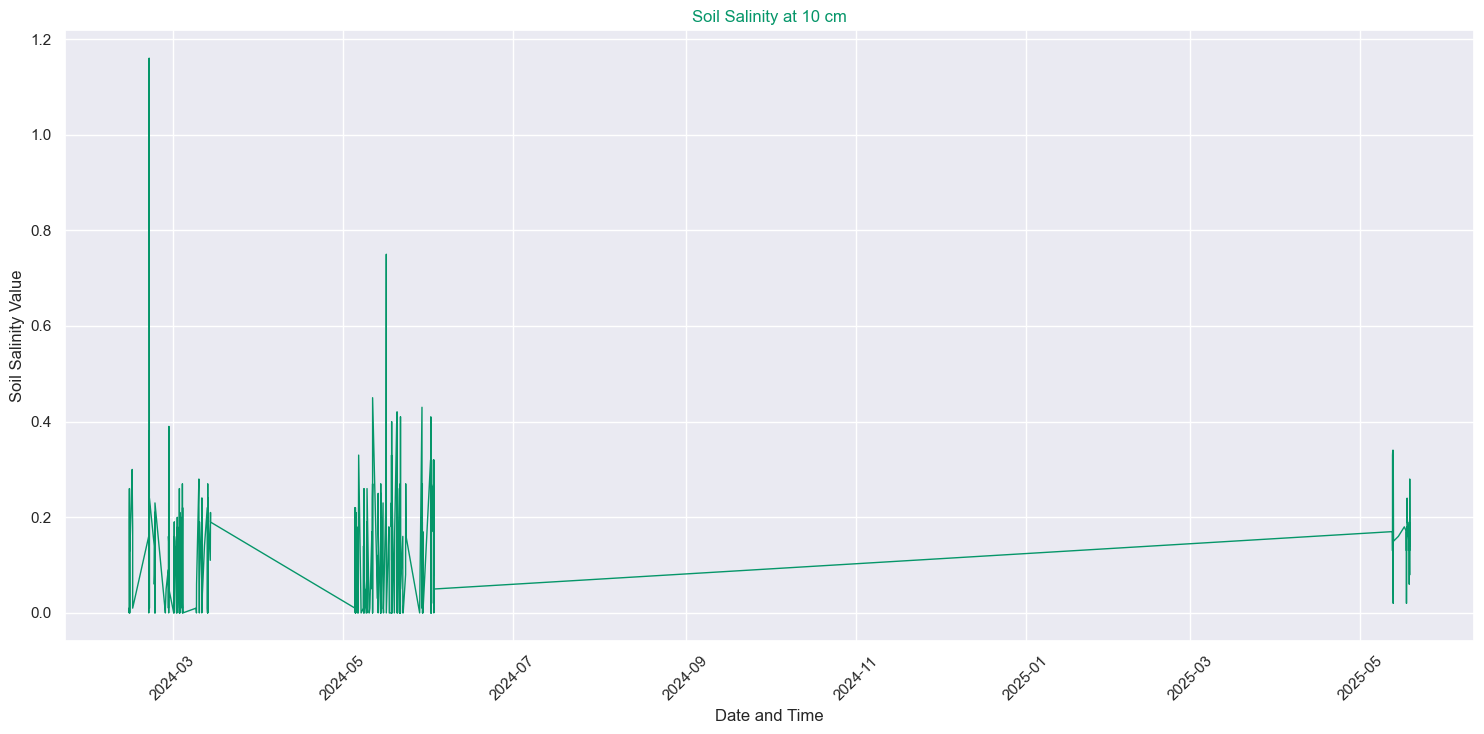

In [36]:
sns.set_theme()
fig, ax = plt.subplots(figsize=(15, 7.5))

ax.plot(Salinity_10['local_time'], Salinity_10['soil_value'],
        linewidth=1, color=MOP_GREEN)

ax.set_xlabel("Date and Time")
ax.set_ylabel("Soil Salinity Value")
ax.set_title("Soil Salinity at 10 cm", color=MOP_GREEN)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()

<div class="usecase-body">

Salinity should not be read the same way as temperature. Temperature follows a daily and seasonal cycle, so its chart is full of regular ups and downs. Salinity responds to watering, rainfall and fertiliser, so step changes and slow drift are what matter. Readings near zero are common and usually genuine: many sites carry very little salt. What matters is a steady rise at one site, which suggests salt is building up faster than it is being flushed away. Where that happens, watering more often makes it worse; deeper, less frequent watering flushes the salt below the roots.

</div>

In [37]:
print(f"{soil_df['site_name'].nunique()} distinct sites in the retrieved readings.")
soil_df['site_name'].unique()[:20]

58 distinct sites in the retrieved readings.


array(['Queen Vic', 'Royal Parade University college',
       'Princess bridge NW p01', 'McAlister Oval',
       'Shrine Reserve South West', 'Carlton Gardens North',
       'Docklands Park South', 'Royal Parade Opposite Lawn 5',
       'Bourke North 5', 'Princes Park Oval 3', 'Bourke North 6 (280)',
       'Ron Barassi Oval', 'Kings Domain West', 'H.G.Smith Oval',
       'Princess bridge NE p11', 'Bandstand', 'Princess bridge SW p10',
       "Fitzroy Gardens East '18", 'Western Oval', 'Flagstaff Gardens 3'],
      dtype=object)

<div id="section-7" class="usecase-section-heading">
    7. From readings to decisions
</div>

<div class="usecase-body">

The scenario at the top asked how soil temperature and salinity behave, so that watering and planting decisions rest on measured conditions. This section pulls the charts together into what they help you decide.

</div>

<div class="usecase-body"><b>Irrigation scheduling</b></div>

<div class="usecase-body">

The depth comparison in section 4.2 is the case for scheduling on root-zone rather than surface conditions. Because the deeper readings lag behind the shallow ones, a schedule triggered by surface conditions waters in response to a change the roots have not felt yet. The size of that lag is the number a schedule should be built around.

</div>

<div class="usecase-body"><b>Site prioritisation</b></div>

<div class="usecase-body">

Sites where salinity is rising need a different response from sites that are simply dry, and the two look the same without this data. Watering a salty site more often adds salt as fast as it dilutes it. Ranking sites by salinity trend gives a shortlist, and the map turns that shortlist into a route.

</div>

<div class="usecase-body"><b>Planting decisions</b></div>

<div class="usecase-body">

The distributions in section 4.3 describe the range of conditions a plant would experience across the whole period, not just on one day. A site with a wide temperature range and rising salinity suits hardier species. This is the kind of question a sensor network can answer and a weather station cannot.

</div>

<div class="usecase-body"><b>Network coverage</b></div>

<div class="usecase-body">

The clustered map shows where monitoring is thin. Parks with a single sensor carry the most uncertainty, because there is nothing to compare against and a fault would go unnoticed. Those sites, and the gaps between clusters, are where another sensor would add the most.

</div>

<div id="conclusion" class="usecase-unnumbered-heading"><b>Conclusion</b></div>

<div class="usecase-body"><b>What we achieved in this analysis</b></div>

<div class="usecase-body">

This analysis took the City of Melbourne soil sensor network from a live API through to a set of charts, a map, and a set of decisions those outputs support. Two datasets were retrieved and used together: the readings, which carry the measurements but no coordinates, and the locations, which carry the coordinates but no measurements.

The readings were tidied out of an inconsistent label scheme, split by depth, and compared at 10, 20 and 30 cm as both time series and distributions. The network was then mapped, first as individual markers and then clustered. The same approach was applied to salinity, and section 7 turned the results into watering, prioritisation, planting and coverage decisions.

</div>

<div class="usecase-body"><b>What we learned from this analysis</b></div>

<div class="usecase-body">

Depth changes how soil temperature behaves, not just its level. Shallow readings follow the daily air cycle closely, while deeper readings are insulated and respond later. So a surface reading is a poor guide to the root zone, which is where watering decisions actually apply.

Category labels in real data are rarely as clean as they look. `probe_measure` holds far more values than there are real measurements, because the same reading has been written several ways. Matching one exact label returns part of the data, or none, without raising an error &mdash; and the resulting chart still looks convincing. Tidying the labels first is what makes the comparison trustworthy.

Type conversion is not a formality either. Timestamps left as text are treated as unordered categories, which produces an unreadable axis even though nothing fails.

</div>

<div class="usecase-body"><b>Limitations</b></div>

<div class="usecase-body">

Three limits bound everything above.

The retrieval stops at 9,900 rows, so this is a sample rather than the full history. Seasonal claims cannot be made from it.

Every chart combines all sites into one line. That is fine for seeing how depth behaves, since that holds everywhere, but it cannot support a claim about a particular park. Grouping by `site_name` is the next step.

The readings have not been checked against a second source, so flat runs and sudden jumps may be sensor faults rather than real conditions.

</div>

<div class="usecase-body"><b>Observations for further opportunities</b></div>

<div class="usecase-body">

Grouping by `site_name` is the most valuable next step, and the one that most changes what can be claimed. Every chart here combines the whole network into one line.

Beyond that, joining the readings to the locations and colouring the map markers by a recent reading would turn the map into a picture of current conditions. Pivoting the long format into one column per measure would allow temperature, moisture and salinity at the same site and time to be compared directly. An API key would lift the 10,000 record cap and make seasonal analysis possible. And comparing soil temperature against Bureau of Meteorology air temperature would measure the lag between the surface and the root zone, which is the figure a watering schedule would really be built on.

</div>